# REAL-WORLD EVIDENCE INSIGHTS

Goal: The aim of this analysis is to generate real-world evidence insights from NHS prescribing data using the Prescription Cost Analysis (PCA) dataset for January–April 2026. The analysis explores prescribing volumes, prescription costs, and patterns across therapeutic areas (BNF chapters), products, and preparation categories to identify key drivers of NHS prescribing activity and expenditure.

In [1]:
# setup 
import pandas as pd
import numpy as np

# importing plotting functions library
import sys
sys.path.append("../src")
import Plotting_Functions as pf

# getting the output directory path
from pathlib import Path
Output_dir = Path("../output")

# setting for float display
pd.set_option('display.float_format', '{:,.2f}'.format)


In [2]:
# loading the data set

# Data preparation note: The RWE analysis uses the cleaned PCA dataset after removal of exception records. These records were excluded as they 
# did not contain standard product-level information required for analysis of medicines, appliances, devices, and therapeutic categories.


df_pca_complete = pd.read_parquet("../data/cleaned data/nhs_prescribing_analysis.parquet")

df_pca_complete.head(3)

,year_month,region_name,region_code,icb_name,icb_code,dispenser_account_type,bnf_presentation_code,bnf_presentation_name,snomed_code,supplier_name,...,prescribed_prep_class,items,total_quantity,nic,pharmacy_advanced_service,is_exception_record,year,month,date,month_name
0,202601,NORTH EAST AND YORKSHIRE,Y63,NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...,QOQ,English Pharmacy,0406000F0AAACAC,Cyclizine 50mg tablets,21908911000001104,Teva UK Ltd,...,5,5,500.00,16.80,Not applicable,False,2026,1,2026-01-01,Jan
1,202601,NORTH WEST,Y62,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,QYG,English Dispensing Doctor,1003020AFBBAAAA,Voltarol 1.16% Emulgel,2894011000001109,Haleon UK Trading Ltd,...,3,15,"1,700.00",78.71,Not applicable,False,2026,1,2026-01-01,Jan
2,202601,SOUTH EAST,Y59,NHS SURREY HEARTLANDS INTEGRATED CARE BOARD,QXU,English Pharmacy,0913011S0BBAEAI,Aymes Actagain 2.0 liquid (6 flavours),42993711000001104,Aymes International Ltd,...,3,1,"5,600.00",61.04,Not applicable,False,2026,1,2026-01-01,Jan


In [3]:
# checking the shape of the dataset

df_pca_complete.shape #2.25 million records, 32 columns

(2251563, 32)

## SECTION 1

### Research Question 1: Which products are the key drivers of NHS prescribing costs?

##### Objective: 

To identify products contributing most significantly to NHS prescribing expenditure.

##### ANALYSIS

Top 10 products by NIC (cost)

In [4]:
# load the top products dataset

df_nhs_data = pd.read_csv(Output_dir / "Product_Medicine/top_10_products_nic.csv")

df_nhs_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   generic_bnf_equivalent_name  10 non-null     str    
 1   bnf_chapter                  10 non-null     str    
 2   items                        10 non-null     int64  
 3   total_quantity               10 non-null     float64
 4   nic                          10 non-null     float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.1 KB


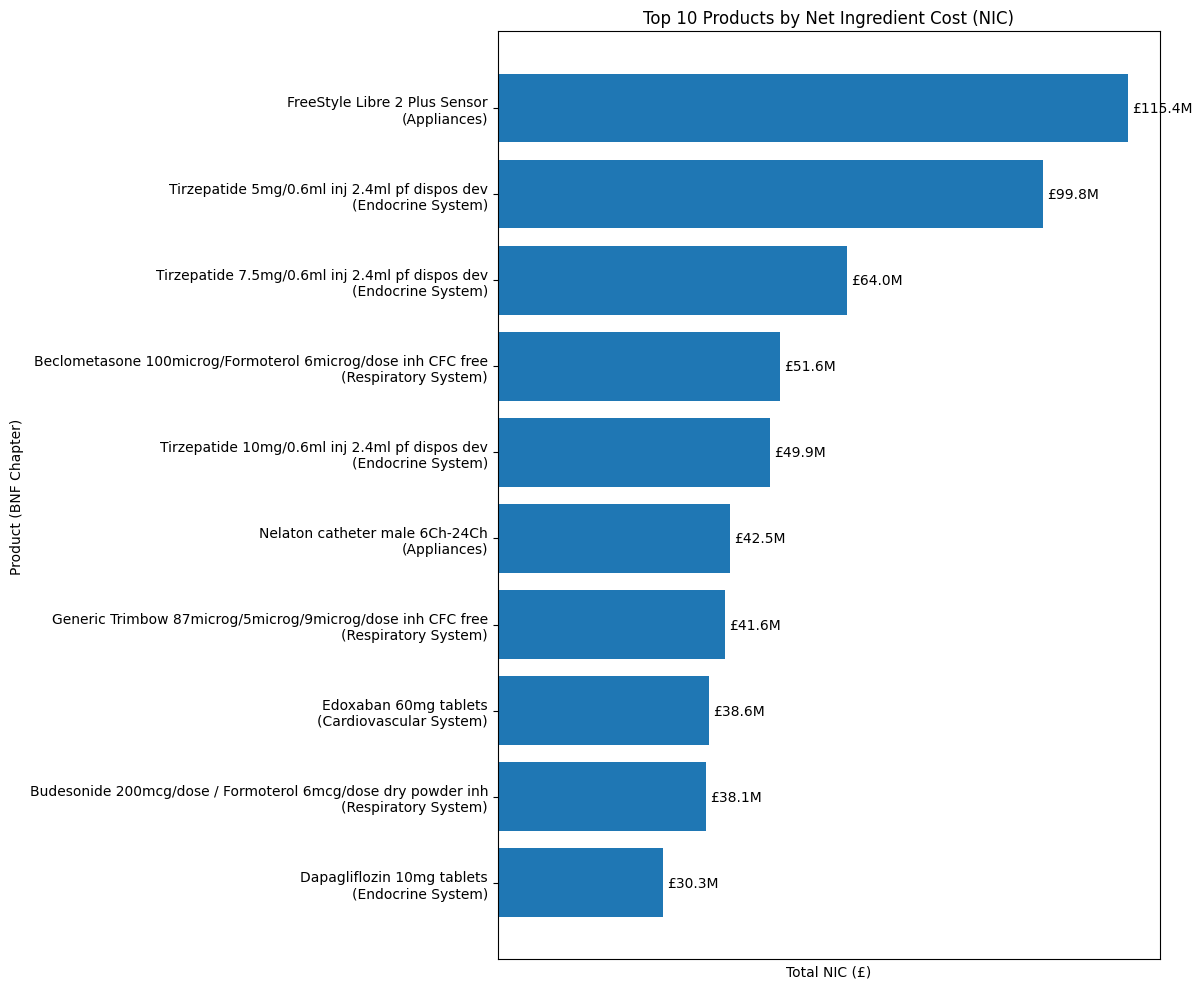

In [5]:
# display the data as a horizontal bar chart

pf.plot_barh(df = df_nhs_data, 
          category_col = "generic_bnf_equivalent_name",
          value_col = "nic",
          title = "Top 10 Products by Net Ingredient Cost (NIC)", 
          ylabel = "Product (BNF Chapter)",
          xlabel = "Total NIC (£)",
          isCurrency=True,
          label_currency= "M",
          extra_label = "bnf_chapter"
        ) 


NHS prescribing expenditure was concentrated among a relatively small number of high-cost products, particularly diabetes technologies (e.g. FreeStyle Libre sensors), injectable metabolic therapies (tirzepatide), respiratory inhalers, and cardiovascular medicines.

In [6]:
# top 10 products by ITEMS
top_10_items = (
                df_pca_complete.groupby(["bnf_chapter","generic_bnf_equivalent_name"])["items"]
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index()
            )

top_10_items

,bnf_chapter,generic_bnf_equivalent_name,items
0,Cardiovascular System,Atorvastatin 20mg tablets,13460092
1,Gastro-Intestinal System,Omeprazole 20mg gastro-resistant capsules,10226308
2,Cardiovascular System,Amlodipine 5mg tablets,8015593
3,Gastro-Intestinal System,Lansoprazole 30mg gastro-resistant capsules,7137506
4,Cardiovascular System,Atorvastatin 40mg tablets,6684543
5,Cardiovascular System,Amlodipine 10mg tablets,5479012
6,Gastro-Intestinal System,Lansoprazole 15mg gastro-resistant capsules,4956079
7,Cardiovascular System,Aspirin 75mg dispersible tablets,4922353
8,Endocrine System,Metformin 500mg tablets,4838092
9,Central Nervous System,Paracetamol 500mg tablets,4521735


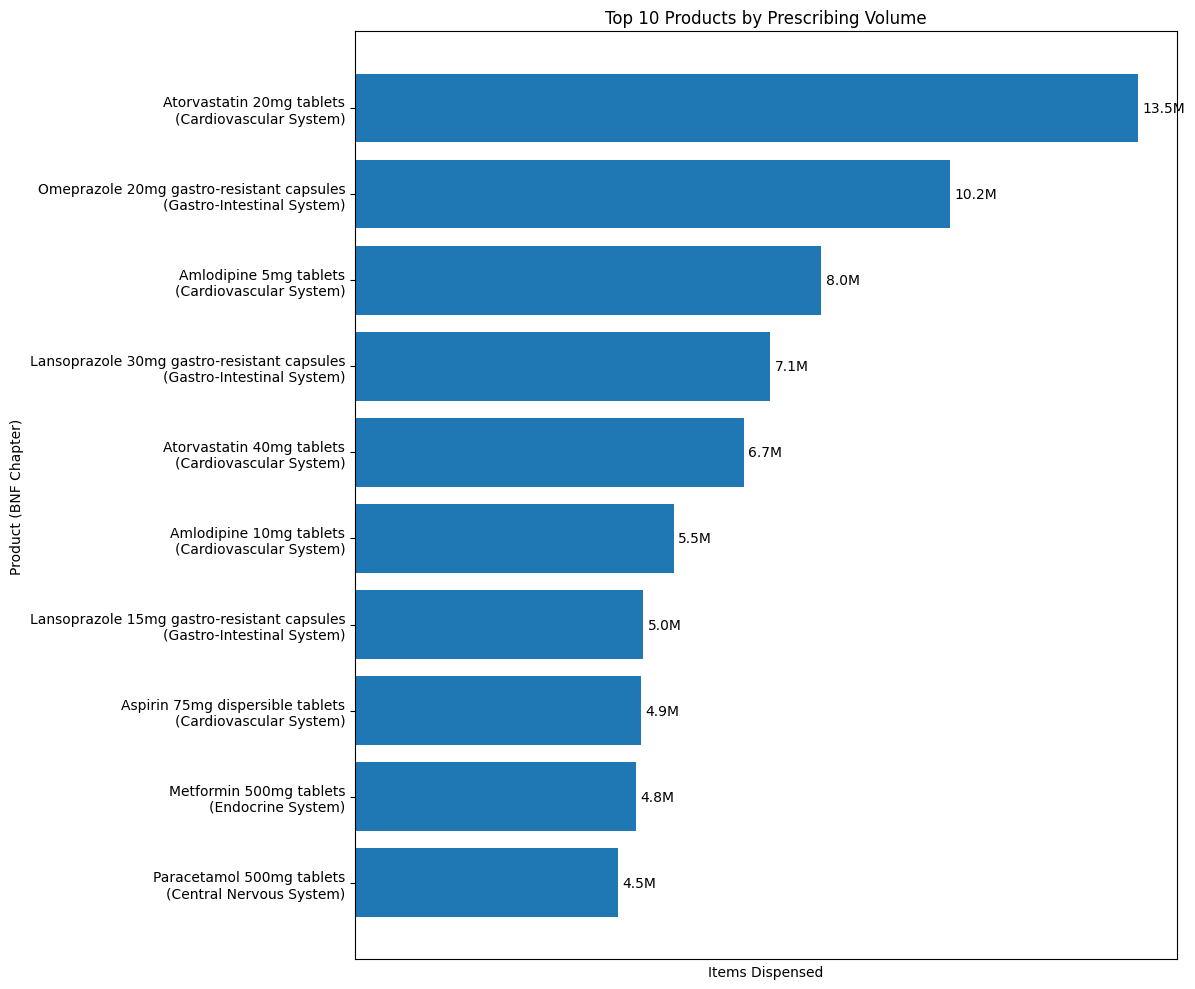

In [7]:
# visualising the result
# display the data as a horizontal bar chart

pf.plot_barh(df = top_10_items, 
          category_col = "generic_bnf_equivalent_name",
          value_col = "items",
          title = "Top 10 Products by Prescribing Volume", 
          ylabel = "Product (BNF Chapter)",
          xlabel = "Items Dispensed",
          isCurrency=False,
          label_currency= "M",
          extra_label = "bnf_chapter"
        ) 



Prescribing volume was dominated by well-established medicines used for the long-term management of common chronic conditions. Cardiovascular medicines (atorvastatin, amlodipine and aspirin), gastrointestinal therapies (omeprazole and lansoprazole), metformin for diabetes, and paracetamol accounted for the highest numbers of items dispensed.

### Overall Insight 

Routine medicines for chronic disease management dominate prescribing volume, whereas a smaller number of advanced therapies and medical technologies account for a disproportionately large share of NHS prescribing expenditure.

## SECTION 2

### Research Question 2: Which BNF chapters account for the greatest NHS prescribing expenditure?

##### Objective: 

To identify the BNF chapters contributing most significantly to NHS prescribing expenditure.

##### ANALYSIS

In [8]:
# Top 10 BNF chapter by cost

chapter_cost = (

                    df_pca_complete.groupby("bnf_chapter")["nic"]
                    .sum()
                    .sort_values(ascending=False)
                    .reset_index()    
               )

chapter_cost


,bnf_chapter,nic
0,Endocrine System,"807,774,074.48"
1,Central Nervous System,"547,955,058.48"
2,Respiratory System,"419,323,704.39"
3,Cardiovascular System,"414,526,521.83"
4,Appliances,"321,050,528.09"
5,Nutrition and Blood,"319,874,150.50"
6,Gastro-Intestinal System,"237,329,022.28"
7,Stoma Appliances,"151,125,396.72"
8,Skin,"106,268,499.63"
9,"Obstetrics, Gynaecology and Urinary-Tract Diso...","104,275,418.40"


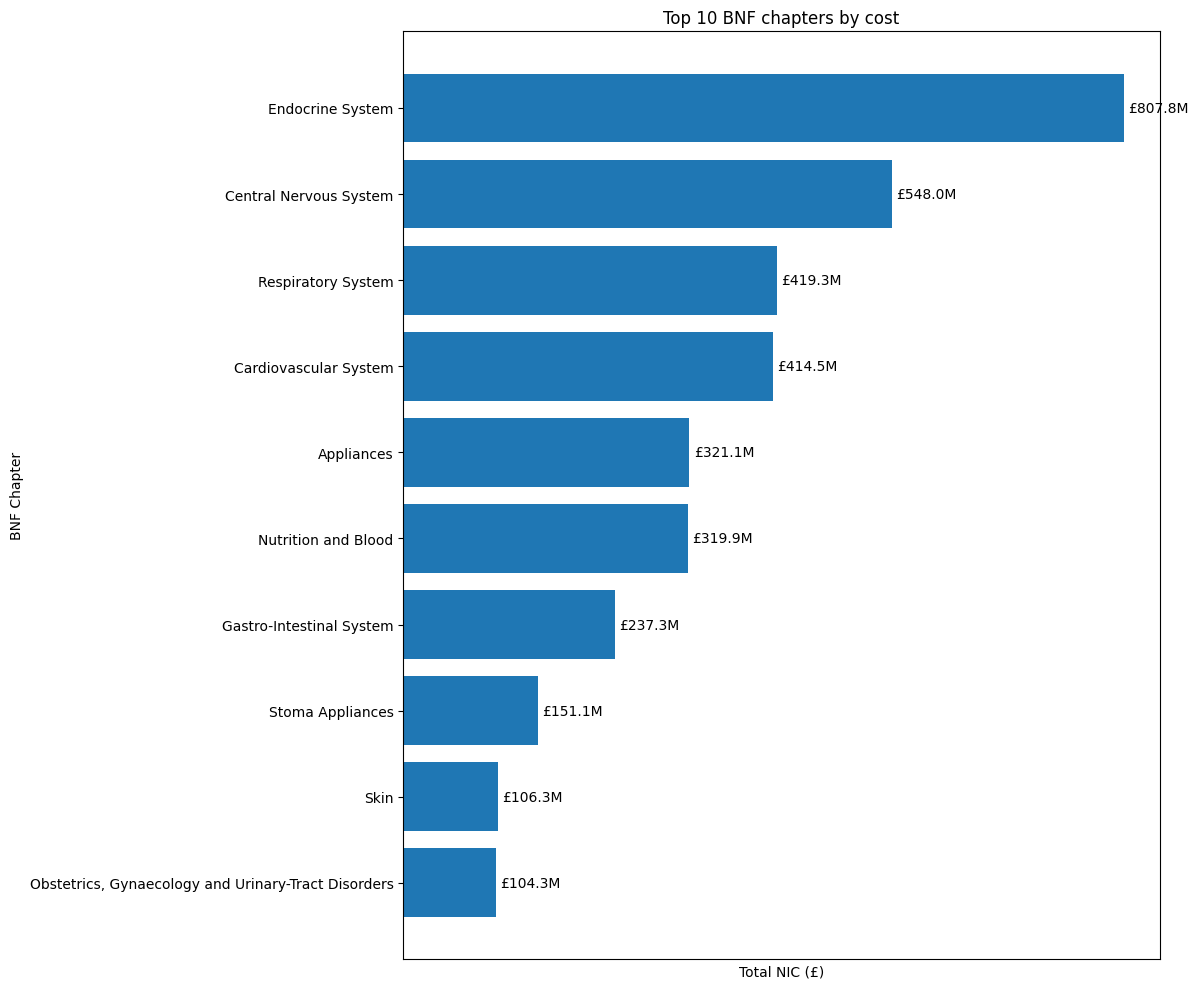

In [9]:
# visualising the top 10 chapter cost data

pf.plot_barh(df = chapter_cost.head(10), 
          category_col = "bnf_chapter",
          value_col = "nic",
          title = "Top 10 BNF chapters by cost", 
          ylabel = "BNF Chapter",
          xlabel = "Total NIC (£)",
          isCurrency=True,
          label_currency= "M"
        ) 


Prescribing expenditure was concentrated within a small number of BNF chapters. The highest-cost therapeutic areas were the Endocrine System, Central Nervous System, and Respiratory System. These findings reflect the significant financial impact of medicines used to manage long-term chronic conditions.

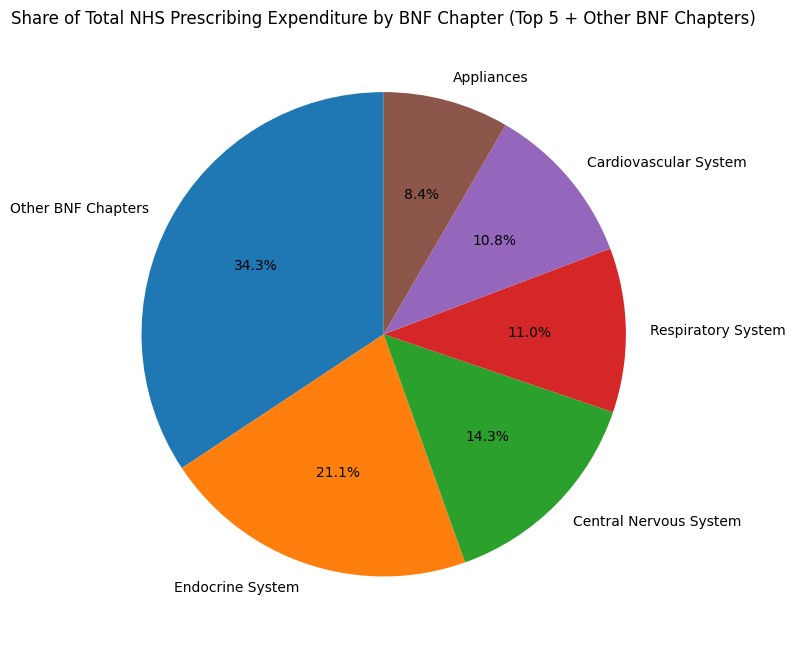

In [10]:
# percentage distribution of top BNF chapters

top_5_chapters = chapter_cost.head(5)


# getting the amount contributed by other (all except the top 5)
others_cost = chapter_cost["nic"].sum() - top_5_chapters["nic"].sum()

pie_data = pd.concat([top_5_chapters, pd.DataFrame({"bnf_chapter" : ["Other BNF Chapters"], 
                                                  "nic" : others_cost})])


# visualising the chapter cost data by percentage breakdown 
pie_data = pie_data.sort_values(
    "nic",
    ascending=False
)

pf.plot_pie_chart(pie_data, 
                  "bnf_chapter",
                  "nic",
                  "Share of Total NHS Prescribing Expenditure by BNF Chapter (Top 5 + Other BNF Chapters)")

###### NOTE: The chart displays the five highest-cost BNF chapters. All remaining chapters(15) have been combined into "Other BNF Chapters" category.

The Endocrine System accounted for the largest share of total NHS prescribing expenditure (21%), followed by the Central Nervous System (14%) and Respiratory System (11%).

### Overall Insight

NHS prescribing expenditure was concentrated within a small number of BNF chapters, with the Endocrine System representing the largest contribution. This suggests that therapeutic areas involving high-cost medicines and technologies have a disproportionate impact on NHS prescribing budgets.

## SECTION 3

### Research Question 3: How have prescribing expenditure trends changed across major therapeutic areas between January and April 2026?

##### Objective: 

To analyse NHS prescribing expenditure trends across major therapeutic areas between January and April 2026.


##### ANALYSIS

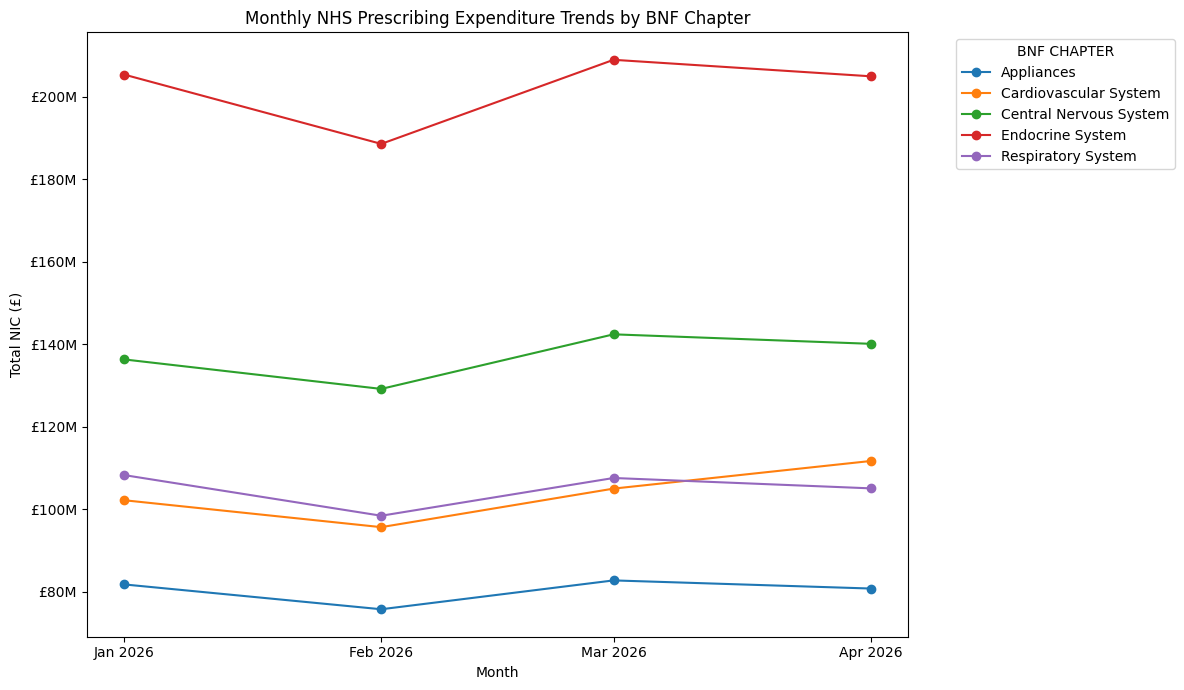

In [11]:
# load the bnf chapter and date dataset

monthly_data = pd.read_csv(Output_dir / "Temporal/monthly_chapter.csv")

# filtering the data for top BNF chapters (from question 2)

top_bnf_chapter = (
                    monthly_data[monthly_data["bnf_chapter"].isin(top_5_chapters["bnf_chapter"])]
                    .groupby(["date", "bnf_chapter"])["nic"]
                    .sum()
                    .reset_index()
                    .sort_values("date")
)

# date column should be a date datatype
top_bnf_chapter["date"] = pd.to_datetime(top_bnf_chapter["date"])

# display the data as a line chart for each category
pf.plot_line_categories(df = top_bnf_chapter, 
          category_col = "date",
          value_col = "nic",
          group_col = "bnf_chapter",
          title = "Monthly NHS Prescribing Expenditure Trends by BNF Chapter", 
          xlabel = "Month",
          ylabel = "Total NIC (£)",
          isCurrency=True,
          label_currency = "M"
        ) 


### Overall Insight

Monthly NHS prescribing expenditure remained relatively stable across the major BNF chapters between January and April 2026. The Endocrine System consistently represented the largest contributor to expenditure, followed by the Central Nervous System and Respiratory System. The persistence of high expenditure across these therapeutic areas reflects ongoing management of chronic conditions.